In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle as pkl
from glob import glob

/Users/kschille/micromamba/envs/info-decom/lib/python3.12/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
file_location = "../data/processed/spikingrate/*.pkl"

files = glob(file_location)

In [5]:
# organize this by region, not eid:
# fix stupid mistake

important_regions = np.asarray(
    [
        "VISp",
        "MOs",
        "SSp-ul",
        "ACAd",
        "PL",
        "CP",
        "VPM",
        "MG",
        "LGd",
        "ZI",
        "SNr",
        "MRN",
        "SCm",
        "PAG",
        "APN",
        "RN",
        "PPN",
        "PRNc",
        "PRNr",
        "GRN",
        "IRN",
        "PGRN",
        "CUL4 5",
        "SIM",
        "IP",
    ]
)

In [6]:
def plot_firing_rate(region_firing_rate_all, reg, title):
    allinone = np.concatenate(region_firing_rate_all)
    region_firing_rate_all.append(allinone)
    colors = ["grey" for i in range(len(region_firing_rate_all) - 1)] + ["#dd4b39"]
    fig, ax = plt.subplots(figsize=(12, 4))
    allinone = np.concatenate(region_firing_rate_all)
    sns.boxenplot(region_firing_rate_all, palette=colors, ax=ax)
    ax.set_xlabel("Animals")
    ax.set_ylabel("Firing rate")
    ax.set_title(f"{reg}-{title}")
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

    plt.savefig(
        "../reports/figures/spiking_rates/{}_{}.png".format(reg, title), bbox_inches="tight"
    )
    plt.close()

    return allinone

In [7]:
def get_idx(interest):
    if interest == "all":
        return 0
    elif interest == "con":
        return 1
    elif interest == "incon":
        return 2
    elif interest == "1":
        return 3
    elif interest == "0.25":
        return 4
    elif interest == "0.125":
        return 5
    elif interest == "0.0625":
        return 6
    elif interest == "0":
        return 7
    elif interest == "session-wide":
        return 8
    else:
        return -1

In [8]:
percentile_limits_all = {}
for reg in important_regions:
    region_firing_rate_all = []
    interest = "all"
    indx_of_interest = get_idx(interest)
    for f in files:
        with open(f, "rb") as f:
            data = pkl.load(f)
        if reg in data.keys():
            region_firing_rate_all.append(data[reg][indx_of_interest, :])  # general firing rate
    percentile = plot_firing_rate(region_firing_rate_all, reg, interest)
    percentile_limits_all[reg] = percentile

In [27]:
# so in the window we want
# we can filter on the firing rate
# so we add different masks in the loading code
# 1. based on firing rate
# 2. based on single cell results
# 3. can i add encoding?

In [9]:
percentile_limits_all.keys()

dict_keys([np.str_('VISp'), np.str_('MOs'), np.str_('SSp-ul'), np.str_('ACAd'), np.str_('PL'), np.str_('CP'), np.str_('VPM'), np.str_('MG'), np.str_('LGd'), np.str_('ZI'), np.str_('SNr'), np.str_('MRN'), np.str_('SCm'), np.str_('PAG'), np.str_('APN'), np.str_('RN'), np.str_('PPN'), np.str_('PRNc'), np.str_('PRNr'), np.str_('GRN'), np.str_('IRN'), np.str_('PGRN'), np.str_('CUL4 5'), np.str_('SIM'), np.str_('IP')])

In [11]:
R = []
for k in percentile_limits_all.keys():
    R.append(percentile_limits_all[k])

/var/folders/y5/6gw6cv4n4cx5h533hmp61vfc0000gq/T/ipykernel_77719/277461819.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(percentile_limits_all.keys()), rotation=90)


Text(0.5, 1.0, 'All regions')

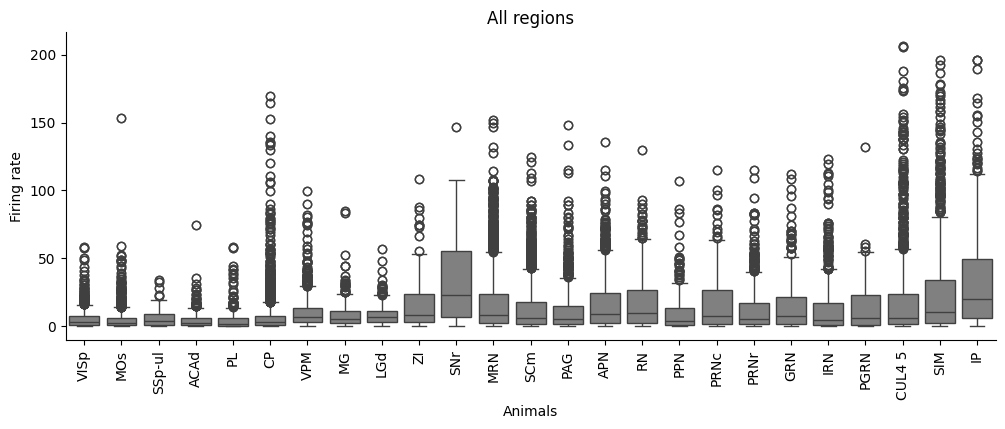

In [28]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(R, color="grey", ax=ax)
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.set_xlabel("Animals")
ax.set_ylabel("Firing rate")
ax.set_xticklabels(list(percentile_limits_all.keys()), rotation=90)
ax.set_title("All regions")

In [1]:
# 1/f frequency plots or something like that

In [155]:
for idx in range(len(R)):
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.histplot(R[idx], fill=True, ax=ax, bins=20)
    limit = np.percentile(R[idx], 25)
    ax.axvline(limit, color="r", linestyle="dashed")
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)
    ax.set_xlabel("Firing rate")
    ax.set_title(list(percentile_limits_all.keys())[idx])
    plt.savefig(
        f"../reports/figures/spiking_rates/{list(percentile_limits_all.keys())[idx]}.png",
        bbox_inches="tight",
    )
    plt.close()

In [40]:
from ibl_info.utils import FIRING_RATE